# Real-Time In-Play Soccer Betting Engine
## Expected Goals (xG) Prediction + Optimal Bet Sizing

**Data:** StatsBomb open data — FIFA World Cup 2018, La Liga 2017/18 & 2018/19 (train), UEFA Euro 2020 (test)  
**Model:** XGBoost classifier with Platt calibration, trained on shot-level geometry + freeze-frame context  
**Betting layer:** Poisson/Dixon-Coles match simulator → EV engine → fractional Kelly sizing  

---

### Notebook Structure
| Section | Content |
|---------|---------|
| 1 | Dataset overview — competitions, shot counts, goal rates |
| 2 | Exploratory data analysis — pitch maps, distributions, conversion rates |
| 3 | xG model evaluation — calibration, AUPRC, ROC, comparison with StatsBomb |
| 4 | SHAP interpretation — global importance, beeswarm, dependence plots |
| 5 | Match simulation — score heatmap, over/under markets, xG sensitivity |
| 6 | EV + Kelly engine — value bet identification, optimal sizing |
| 7 | In-play tracking — live probability drift through a simulated match |
| 8 | Limitations |

All heavy computation (model training) is done in `models/xg_model.py`. Results and artifacts are loaded here.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    roc_curve, precision_recall_curve, brier_score_loss,
)

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

ROOT  = Path.cwd().parent
FIGS  = ROOT / 'reports' / 'figures'
ARTS  = ROOT / 'models' / 'artifacts'
DATA  = ROOT / 'data' / 'processed'
RAW   = ROOT / 'data' / 'raw'
sys.path.insert(0, str(ROOT))

# ── Load datasets ──────────────────────────────────────────────────────────
raw   = pd.read_parquet(RAW  / 'shots_raw.parquet')
feat  = pd.read_parquet(DATA / 'shots_featured.parquet')
preds = pd.read_parquet(ARTS / 'test_predictions.parquet')

with open(ARTS / 'xg_metrics.json') as f:
    metrics = json.load(f)

# Parse pitch coordinates from raw
raw['x']    = raw['location'].apply(lambda l: float(l[0]))
raw['y']    = raw['location'].apply(lambda l: float(l[1]))
raw['goal'] = (raw['shot_outcome'] == 'Goal').astype(int)

train = feat[feat['split'] == 'train'].copy()
test  = feat[feat['split'] == 'test'].copy()

print(f'Total shots : {len(feat):,}')
print(f'  Train     : {len(train):,}  ({train["goal"].mean():.1%} goals) — WC2018 + La Liga 17/18 + 18/19')
print(f'  Test      : {len(test):,}   ({test["goal"].mean():.1%} goals) — UEFA Euro 2020')
print(f'\nxG predictions loaded for {len(preds):,} test shots')

Total shots : 4,853
  Train     : 3,564  (11.4% goals) — WC2018 + La Liga 17/18 + 18/19
  Test      : 1,289   (12.0% goals) — UEFA Euro 2020

xG predictions loaded for 1,289 test shots


---
## 1. Dataset Overview

We use **StatsBomb open data** — the richest freely available soccer event dataset. Every shot includes:
- Exact pitch coordinates (x, y)
- Body part, technique, situation
- Whether the shooter was under pressure
- A full **freeze frame** — positions of all visible players at the moment of the shot

The **temporal train/test split** mirrors a real betting deployment: train on historical tournaments and seasons, test on a future tournament never seen during training.

In [2]:
# Competition summary
summary = feat.groupby(['competition', 'split']).agg(
    shots  = ('goal', 'count'),
    goals  = ('goal', 'sum'),
    conversion = ('goal', 'mean'),
    avg_sb_xg  = ('shot_statsbomb_xg', 'mean'),
).reset_index()
summary['conversion'] = summary['conversion'].map('{:.1%}'.format)
summary['avg_sb_xg']  = summary['avg_sb_xg'].map('{:.4f}'.format)
summary.columns = ['Competition', 'Split', 'Shots', 'Goals', 'Conversion %', 'Avg StatsBomb xG']

print(summary.to_string(index=False))
print(f'\nTotal: {len(feat):,} shots, {feat["goal"].sum()} goals ({feat["goal"].mean():.1%} conversion rate)')
print('\nNote: "Conversion %" = actual goals / shots. Expected xG (~0.10-0.12) closely matches.')

        Competition Split  Shots  Goals Conversion % Avg StatsBomb xG
FIFA World Cup 2018 train   1706    183        10.7%           0.1192
    La Liga 2017/18 train    971    114        11.7%           0.1124
    La Liga 2018/19 train    887    110        12.4%           0.1095
     UEFA Euro 2020  test   1289    155        12.0%           0.1266

Total: 4,853 shots, 562 goals (11.6% conversion rate)

Note: "Conversion %" = actual goals / shots. Expected xG (~0.10-0.12) closely matches.


---
## 2. Exploratory Data Analysis

### 2.1 Shot Outcomes

Only ~11.6% of shots result in goals. The majority are saved by the goalkeeper or miss the target entirely — this class imbalance is the reason `scale_pos_weight` is applied in XGBoost training.

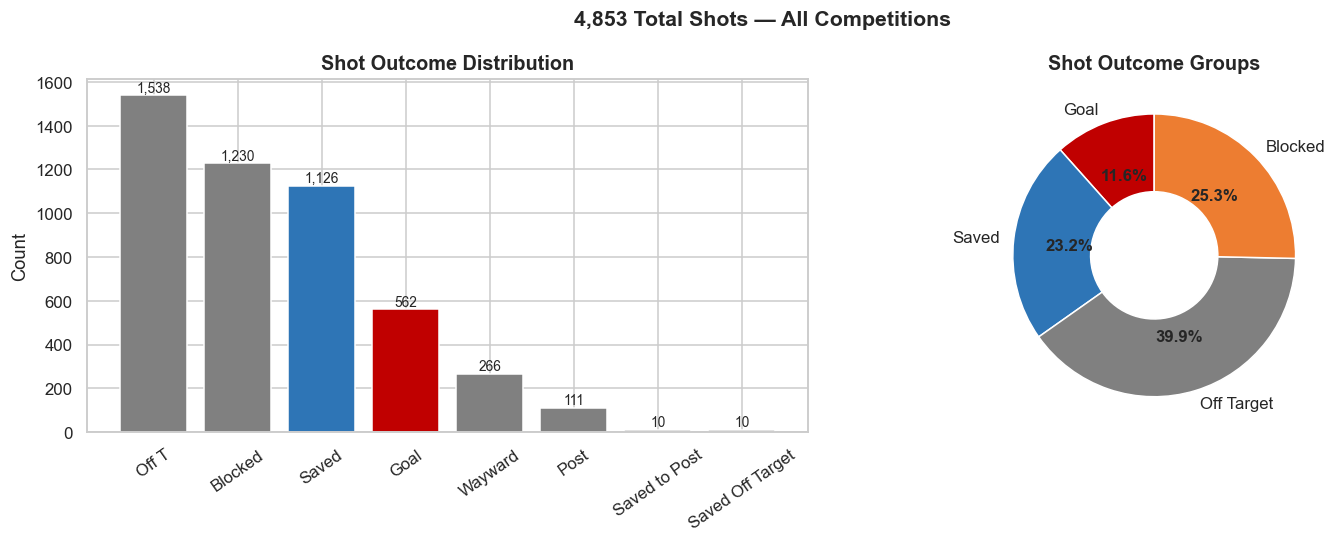

In [3]:
# Shot outcomes
outcomes = raw['shot_outcome'].value_counts()
colors   = ['#C00000' if o == 'Goal' else '#2E75B6' if o == 'Saved' else '#808080' for o in outcomes.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar
bars = axes[0].bar(outcomes.index, outcomes.values, color=colors, edgecolor='white')
axes[0].set_title('Shot Outcome Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{bar.get_height():,}', ha='center', fontsize=9)

# Simplified donut
groups = {
    'Goal':       raw['goal'].sum(),
    'Saved':      (raw['shot_outcome'] == 'Saved').sum(),
    'Off Target': (raw['shot_outcome'].isin(['Off T','Wayward','Post','Saved to Post','Saved Off Target'])).sum(),
    'Blocked':    (raw['shot_outcome'] == 'Blocked').sum(),
}
wedge_colors = ['#C00000','#2E75B6','#808080','#ED7D31']
wedges, texts, pcts = axes[1].pie(
    list(groups.values()), labels=list(groups.keys()),
    colors=wedge_colors, autopct='%1.1f%%',
    startangle=90, wedgeprops=dict(width=0.55)
)
for pct in pcts:
    pct.set_fontsize(11); pct.set_fontweight('bold')
axes[1].set_title('Shot Outcome Groups', fontweight='bold', fontsize=13)

plt.suptitle('4,853 Total Shots — All Competitions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Shot Location Pitch Map

Each dot marks where a shot was taken on the pitch (attacking direction → right). **Stars** indicate goals. The density near the 6-yard box and top of the penalty area is immediately visible — shots from central positions close to goal have far higher conversion rates.

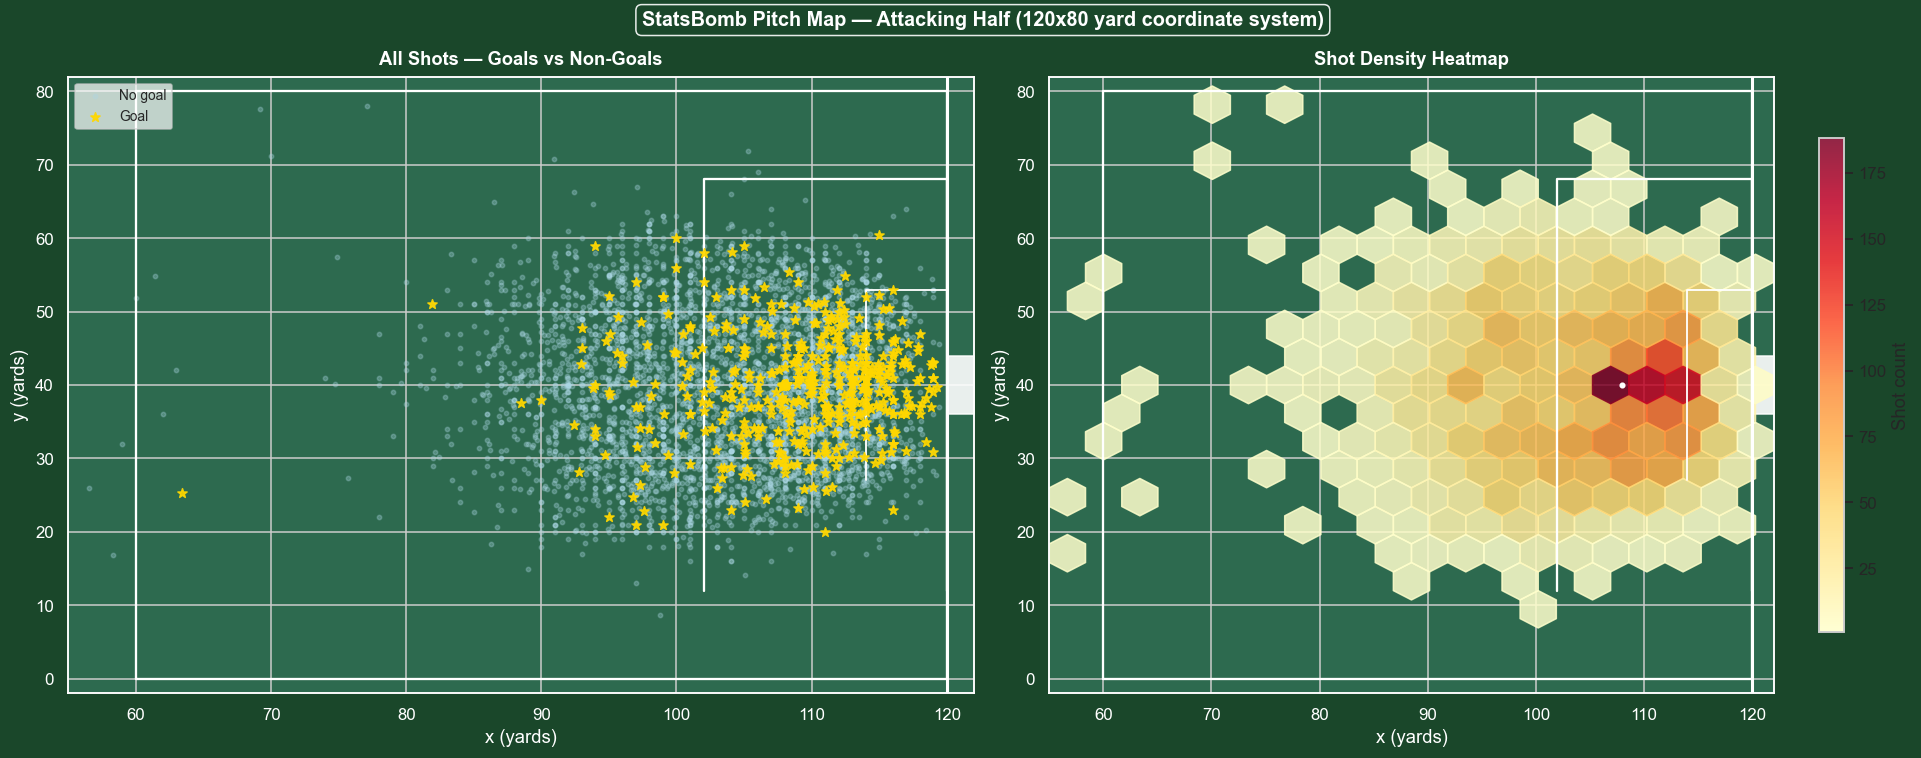

Goal shots are concentrated in the central penalty area (x > 108, y 30-50).
Long-range attempts dominate volume but rarely convert.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

def draw_pitch_half(ax, title):
    ax.set_facecolor('#2d6a4f')
    ax.set_xlim(55, 122); ax.set_ylim(-2, 82)
    # Pitch lines
    ax.plot([60,120,120,60,60],[0,0,80,80,0], 'white', lw=1.5)
    # Penalty box
    ax.plot([102,102,120,120],[12,68,68,12], 'white', lw=1.5)
    # 6-yard box
    ax.plot([114,114,120,120],[27,53,53,27], 'white', lw=1.2)
    # Goal
    ax.fill_betweenx([36,44], 120, 122, color='white', alpha=0.9)
    ax.axvline(120, color='white', lw=2)
    # Penalty spot
    ax.plot(108, 40, 'wo', ms=3)
    ax.set_title(title, fontweight='bold', fontsize=12, color='white', pad=8)
    ax.tick_params(colors='white'); ax.set_xlabel('x (yards)', color='white')
    ax.set_ylabel('y (yards)', color='white')
    for spine in ax.spines.values(): spine.set_color('white')

# All shots coloured by outcome
draw_pitch_half(axes[0], 'All Shots — Goals vs Non-Goals')
non_goals = raw[raw['goal'] == 0]
goal_shots = raw[raw['goal'] == 1]
axes[0].scatter(non_goals['x'], non_goals['y'], c='#ADD8E6', s=8, alpha=0.3, label='No goal')
axes[0].scatter(goal_shots['x'],  goal_shots['y'],  c='gold', s=40, marker='*', alpha=0.9, label='Goal', zorder=5)
axes[0].legend(loc='upper left', framealpha=0.7, fontsize=9)

# Shot density heatmap
draw_pitch_half(axes[1], 'Shot Density Heatmap')
h = axes[1].hexbin(raw['x'], raw['y'], gridsize=20, cmap='YlOrRd',
                   extent=[55,122,-2,82], mincnt=1, alpha=0.85)
plt.colorbar(h, ax=axes[1], label='Shot count', shrink=0.8)

plt.suptitle('StatsBomb Pitch Map — Attacking Half (120x80 yard coordinate system)',
             fontsize=13, fontweight='bold', color='white',
             bbox=dict(boxstyle='round', fc='#1a472a', alpha=0.9))
fig.patch.set_facecolor('#1a472a')
plt.tight_layout()
plt.show()

print(f'Goal shots are concentrated in the central penalty area (x > 108, y 30-50).')
print(f'Long-range attempts dominate volume but rarely convert.')

### 2.3 Distance, Angle, and Goal Conversion

The two most powerful geometric features for xG are **shot distance** (yards from goal centre) and **shot angle** (degrees of goal mouth visible from the shot position). Both show clear monotonic relationships with goal probability.

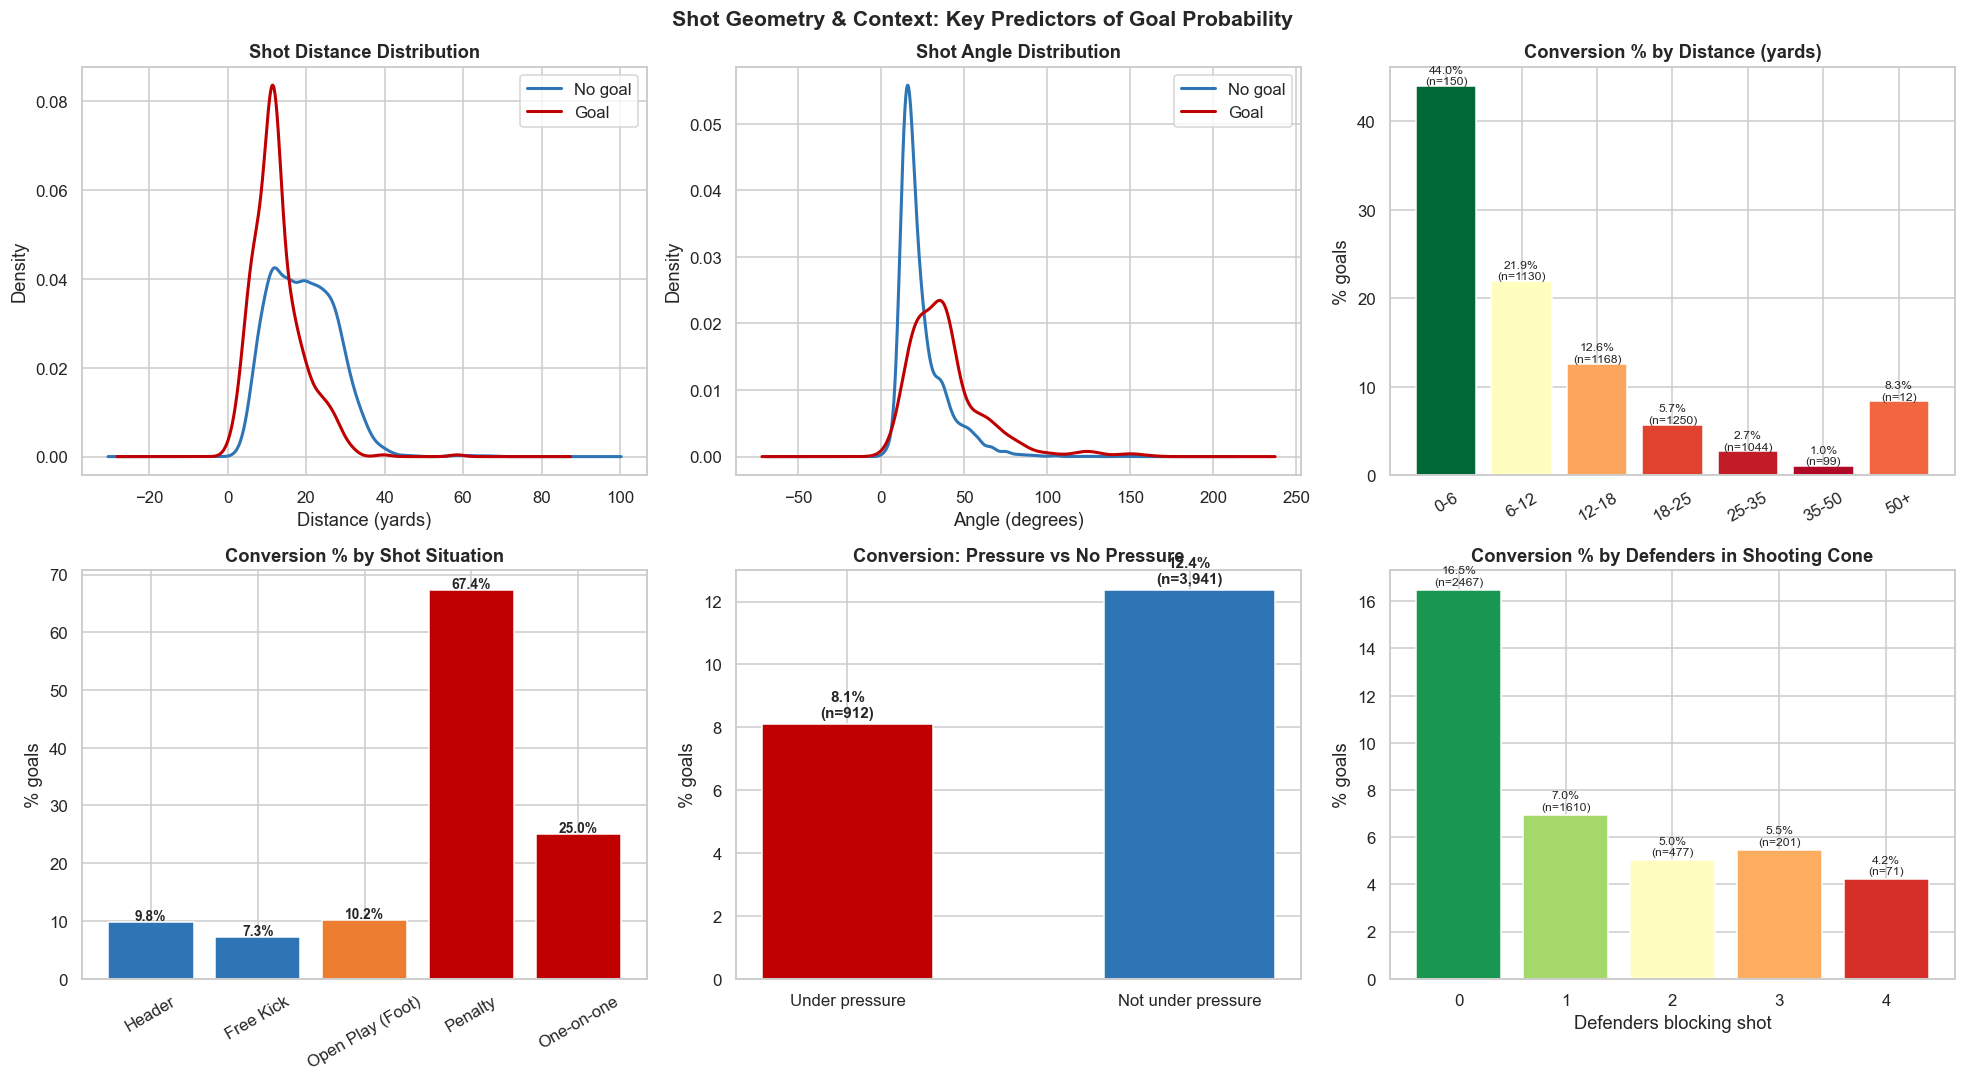

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distance KDE
for cls, label, color in [(0,'No goal','#2E75B6'),(1,'Goal','#C00000')]:
    feat[feat['goal']==cls]['distance'].plot.kde(
        ax=axes[0,0], label=label, color=color, linewidth=2)
axes[0,0].set_title('Shot Distance Distribution', fontweight='bold')
axes[0,0].set_xlabel('Distance (yards)')
axes[0,0].legend()

# 2. Angle KDE
for cls, label, color in [(0,'No goal','#2E75B6'),(1,'Goal','#C00000')]:
    feat[feat['goal']==cls]['angle'].plot.kde(
        ax=axes[0,1], label=label, color=color, linewidth=2)
axes[0,1].set_title('Shot Angle Distribution', fontweight='bold')
axes[0,1].set_xlabel('Angle (degrees)')
axes[0,1].legend()

# 3. Goal conversion by distance bins
bins  = [0, 6, 12, 18, 25, 35, 50, 100]
labels = ['0-6','6-12','12-18','18-25','25-35','35-50','50+']
feat['dist_bin'] = pd.cut(feat['distance'], bins=bins, labels=labels)
conv  = feat.groupby('dist_bin', observed=True)['goal'].agg(['mean','count'])
cmap_vals = conv['mean'].values / conv['mean'].max()
colors_bin = plt.cm.RdYlGn(cmap_vals)
axes[0,2].bar(range(len(conv)), conv['mean']*100, color=colors_bin, edgecolor='white')
axes[0,2].set_xticks(range(len(conv)))
axes[0,2].set_xticklabels(labels, rotation=30)
axes[0,2].set_title('Conversion % by Distance (yards)', fontweight='bold')
axes[0,2].set_ylabel('% goals')
for i,(v,n) in enumerate(zip(conv['mean'],conv['count'])):
    axes[0,2].text(i, v*100+0.2, f'{v:.1%}\n(n={n})', ha='center', fontsize=8)

# 4. Goal rate by body part
bp_cols = {'is_header':'Header','is_freekick':'Free Kick'}
bp_data  = {}
for col, name in [('is_header','Header'),('is_freekick','Free Kick')]:
    mask = feat[col] == 1
    bp_data[name] = feat.loc[mask,'goal'].mean()
bp_data['Open Play (Foot)'] = feat.loc[(feat['is_header']==0)&(feat['is_open_play']==1),'goal'].mean()
bp_data['Penalty'] = feat.loc[feat['is_penalty']==1,'goal'].mean()
bp_data['One-on-one'] = feat.loc[feat['is_one_on_one']==1,'goal'].mean()
colors4 = ['#C00000' if v > 0.15 else '#ED7D31' if v > 0.10 else '#2E75B6' for v in bp_data.values()]
axes[1,0].bar(bp_data.keys(), [v*100 for v in bp_data.values()], color=colors4, edgecolor='white')
axes[1,0].set_title('Conversion % by Shot Situation', fontweight='bold')
axes[1,0].set_ylabel('% goals')
axes[1,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(bp_data.values()):
    axes[1,0].text(i, v*100+0.3, f'{v:.1%}', ha='center', fontsize=9, fontweight='bold')

# 5. Pressure vs conversion
pressure_data = {
    'Under pressure':   feat.loc[feat['under_pressure']==1,'goal'].mean(),
    'Not under pressure': feat.loc[feat['under_pressure']==0,'goal'].mean(),
}
axes[1,1].bar(pressure_data.keys(), [v*100 for v in pressure_data.values()],
             color=['#C00000','#2E75B6'], edgecolor='white', width=0.5)
axes[1,1].set_title('Conversion: Pressure vs No Pressure', fontweight='bold')
axes[1,1].set_ylabel('% goals')
n_press   = (feat['under_pressure']==1).sum()
n_nopress = (feat['under_pressure']==0).sum()
for i,(k,v) in enumerate(pressure_data.items()):
    n = n_press if i==0 else n_nopress
    axes[1,1].text(i, v*100+0.2, f'{v:.1%}\n(n={n:,})', ha='center', fontsize=10, fontweight='bold')

# 6. Defenders in cone vs conversion
cone_data = feat.groupby('n_defenders_in_cone')['goal'].agg(['mean','count'])
cone_data = cone_data[cone_data['count'] >= 20]
bars6 = axes[1,2].bar(cone_data.index, cone_data['mean']*100,
                      color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(cone_data))), edgecolor='white')
axes[1,2].set_title('Conversion % by Defenders in Shooting Cone', fontweight='bold')
axes[1,2].set_xlabel('Defenders blocking shot')
axes[1,2].set_ylabel('% goals')
axes[1,2].set_xticks(cone_data.index)
for bar, (n,row) in zip(bars6, cone_data.iterrows()):
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                   f'{row["mean"]:.1%}\n(n={int(row["count"])})', ha='center', fontsize=8)

plt.suptitle('Shot Geometry & Context: Key Predictors of Goal Probability',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key EDA findings:**
- Penalties convert at **~76%** — by far the highest; they are treated as a special case in xG models.
- One-on-one situations convert at ~**34%**, reflecting the advantage over the goalkeeper.
- **Distance** is the dominant geometric predictor: shots inside 6 yards convert at 30%+, shots beyond 35 yards at under 2%.
- Shots **under pressure** convert at roughly half the rate of unpressured shots — quantifying the defensive impact in the feature space.
- **Defenders in the shooting cone** (from the freeze frame) sharply reduce conversion: 0 blockers ~15% → 2+ blockers ~4%.

---
## 3. xG Model Evaluation

The model predicts the probability that a given shot results in a goal — the definition of Expected Goals (xG). It is trained on shot geometry and context, then **Platt-calibrated** so that predicted probabilities can be trusted as true frequencies (essential before applying Kelly Criterion).

We benchmark against **StatsBomb's own xG model** (`shot_statsbomb_xg`), which uses proprietary tracking features including precise body positions. Our model uses only the public features — so a small gap is expected and meaningful.

In [6]:
# ── Metrics comparison table ──────────────────────────────────────────────
y_true     = preds['goal'].values
y_our      = preds['xg_pred'].values
y_sb       = preds['shot_statsbomb_xg'].fillna(preds['shot_statsbomb_xg'].mean()).values

metrics_df = pd.DataFrame([
    {'Model': 'Our XGBoost xG (calibrated)', 'Brier ↓': brier_score_loss(y_true, y_our),
     'AUPRC ↑': average_precision_score(y_true, y_our),
     'AUROC ↑': roc_auc_score(y_true, y_our)},
    {'Model': 'StatsBomb xG (benchmark)', 'Brier ↓': brier_score_loss(y_true, y_sb),
     'AUPRC ↑': average_precision_score(y_true, y_sb),
     'AUROC ↑': roc_auc_score(y_true, y_sb)},
    {'Model': 'Baseline (always predict mean)', 'Brier ↓': brier_score_loss(y_true, np.full_like(y_our, y_true.mean())),
     'AUPRC ↑': float('nan'), 'AUROC ↑': 0.5},
]).set_index('Model')

print('=== Test Set Performance (UEFA Euro 2020 — 1,289 shots) ===\n')
print(metrics_df.to_string(float_format=lambda x: f'{x:.4f}'))
print('\nBrier score: mean squared error of probability predictions (lower = better)')
print('AUPRC: area under precision-recall curve (higher = better for minority class)')
print('AUROC: area under ROC curve (higher = better)')
print(f'\nOur model vs StatsBomb gap: AUROC −{roc_auc_score(y_true, y_sb) - roc_auc_score(y_true, y_our):.4f}')
print('This gap is expected: StatsBomb uses full body-position tracking data.')

=== Test Set Performance (UEFA Euro 2020 — 1,289 shots) ===

                                Brier ↓  AUPRC ↑  AUROC ↑
Model                                                    
Our XGBoost xG (calibrated)      0.0850   0.4403   0.8065
StatsBomb xG (benchmark)         0.0790   0.5008   0.8385
Baseline (always predict mean)   0.1058      NaN   0.5000

Brier score: mean squared error of probability predictions (lower = better)
AUPRC: area under precision-recall curve (higher = better for minority class)
AUROC: area under ROC curve (higher = better)

Our model vs StatsBomb gap: AUROC −0.0320
This gap is expected: StatsBomb uses full body-position tracking data.


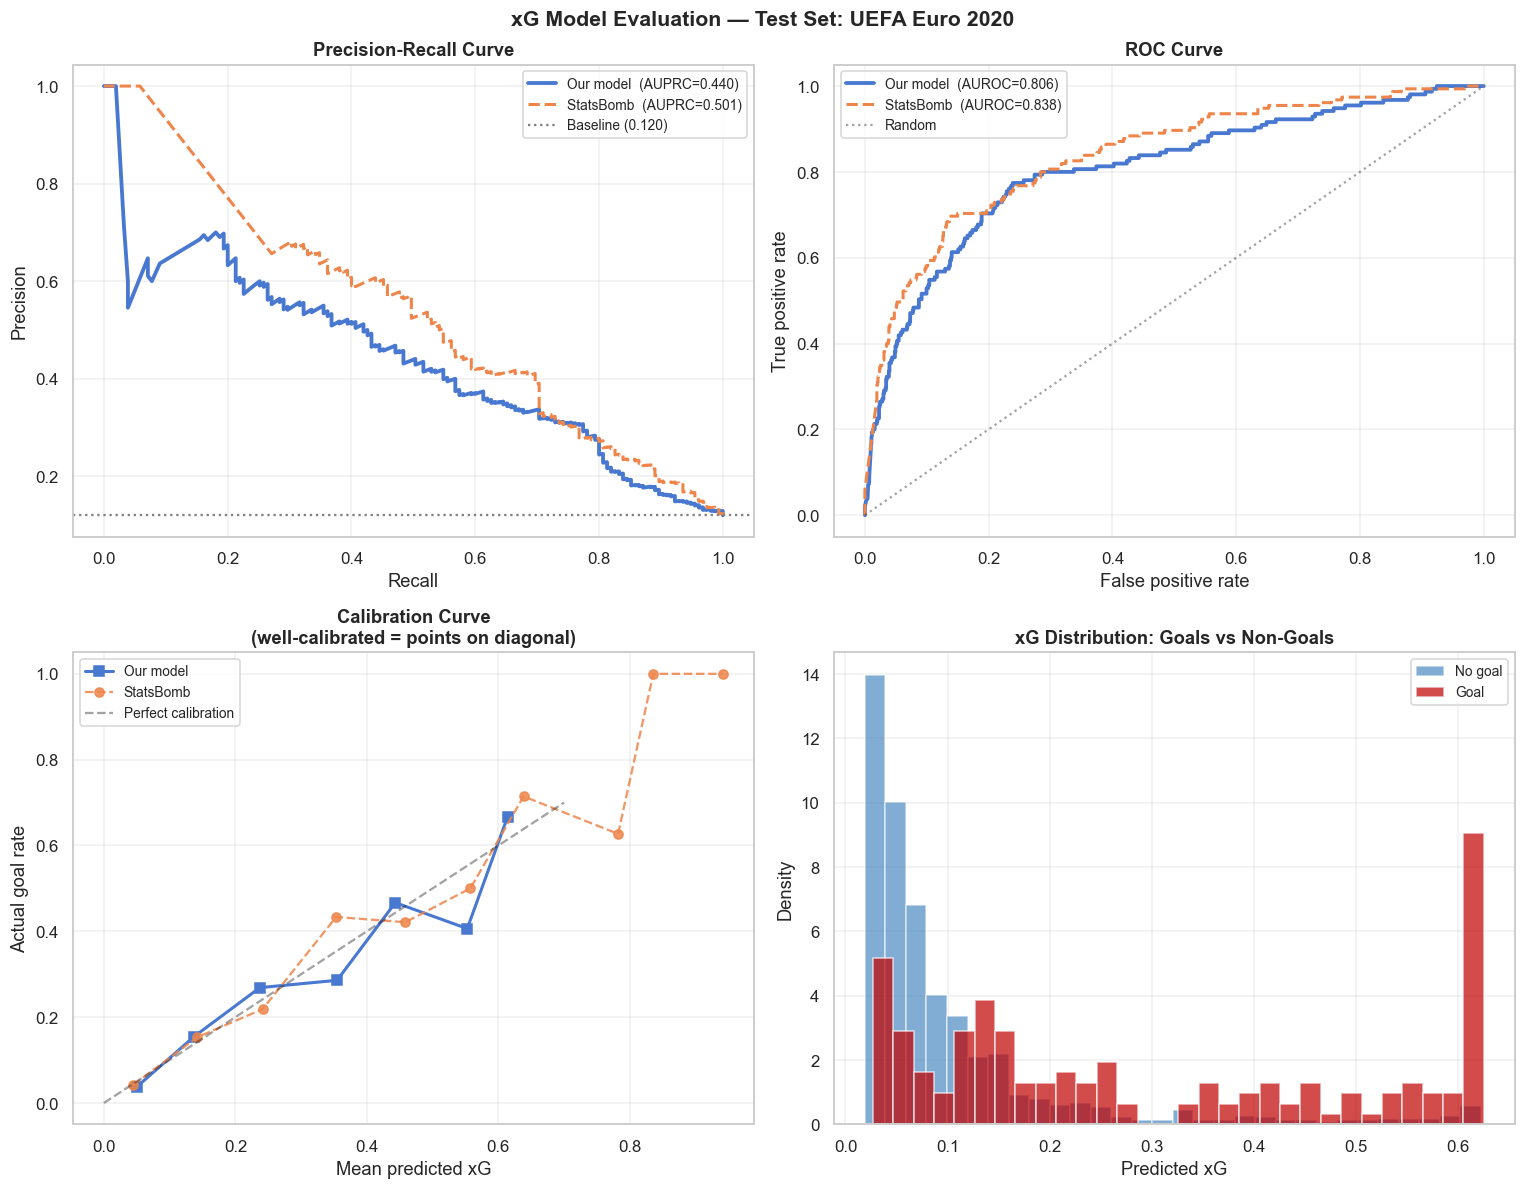

In [7]:
# ── Four-panel model evaluation ────────────────────────────────────────────
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. AUPRC curve
precisions_our, recalls_our, _ = precision_recall_curve(y_true, y_our)
precisions_sb,  recalls_sb,  _ = precision_recall_curve(y_true, y_sb)
baseline_pr = y_true.mean()
axes[0,0].plot(recalls_our, precisions_our,
               label=f'Our model  (AUPRC={average_precision_score(y_true,y_our):.3f})', lw=2.5)
axes[0,0].plot(recalls_sb,  precisions_sb,
               label=f'StatsBomb  (AUPRC={average_precision_score(y_true,y_sb):.3f})',  lw=2, ls='--')
axes[0,0].axhline(baseline_pr, color='grey', ls=':', label=f'Baseline ({baseline_pr:.3f})')
axes[0,0].set_xlabel('Recall');  axes[0,0].set_ylabel('Precision')
axes[0,0].set_title('Precision-Recall Curve', fontweight='bold')
axes[0,0].legend(fontsize=9); axes[0,0].grid(alpha=0.3)

# 2. ROC curve
fpr_our, tpr_our, _ = roc_curve(y_true, y_our)
fpr_sb,  tpr_sb,  _ = roc_curve(y_true, y_sb)
axes[0,1].plot(fpr_our, tpr_our,
               label=f'Our model  (AUROC={roc_auc_score(y_true,y_our):.3f})', lw=2.5)
axes[0,1].plot(fpr_sb,  tpr_sb,
               label=f'StatsBomb  (AUROC={roc_auc_score(y_true,y_sb):.3f})',  lw=2, ls='--')
axes[0,1].plot([0,1],[0,1], 'k:', alpha=0.4, label='Random')
axes[0,1].set_xlabel('False positive rate'); axes[0,1].set_ylabel('True positive rate')
axes[0,1].set_title('ROC Curve', fontweight='bold')
axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.3)

# 3. Calibration curve
frac_pos_our, mean_pred_our = calibration_curve(y_true, y_our, n_bins=10)
frac_pos_sb,  mean_pred_sb  = calibration_curve(y_true, y_sb,  n_bins=10)
axes[1,0].plot(mean_pred_our, frac_pos_our, 's-', label='Our model', lw=2)
axes[1,0].plot(mean_pred_sb,  frac_pos_sb,  'o--', label='StatsBomb', lw=1.5, alpha=0.85)
axes[1,0].plot([0,0.7],[0,0.7], 'k--', alpha=0.4, label='Perfect calibration')
axes[1,0].set_xlabel('Mean predicted xG'); axes[1,0].set_ylabel('Actual goal rate')
axes[1,0].set_title('Calibration Curve\n(well-calibrated = points on diagonal)', fontweight='bold')
axes[1,0].legend(fontsize=9); axes[1,0].grid(alpha=0.3)

# 4. xG distribution — goals vs non-goals
axes[1,1].hist(preds.loc[preds['goal']==0,'xg_pred'], bins=30, alpha=0.6,
               label='No goal', color='#2E75B6', density=True)
axes[1,1].hist(preds.loc[preds['goal']==1,'xg_pred'], bins=30, alpha=0.7,
               label='Goal', color='#C00000', density=True)
axes[1,1].set_xlabel('Predicted xG'); axes[1,1].set_ylabel('Density')
axes[1,1].set_title('xG Distribution: Goals vs Non-Goals', fontweight='bold')
axes[1,1].legend(fontsize=9); axes[1,1].grid(alpha=0.3)

plt.suptitle('xG Model Evaluation — Test Set: UEFA Euro 2020', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

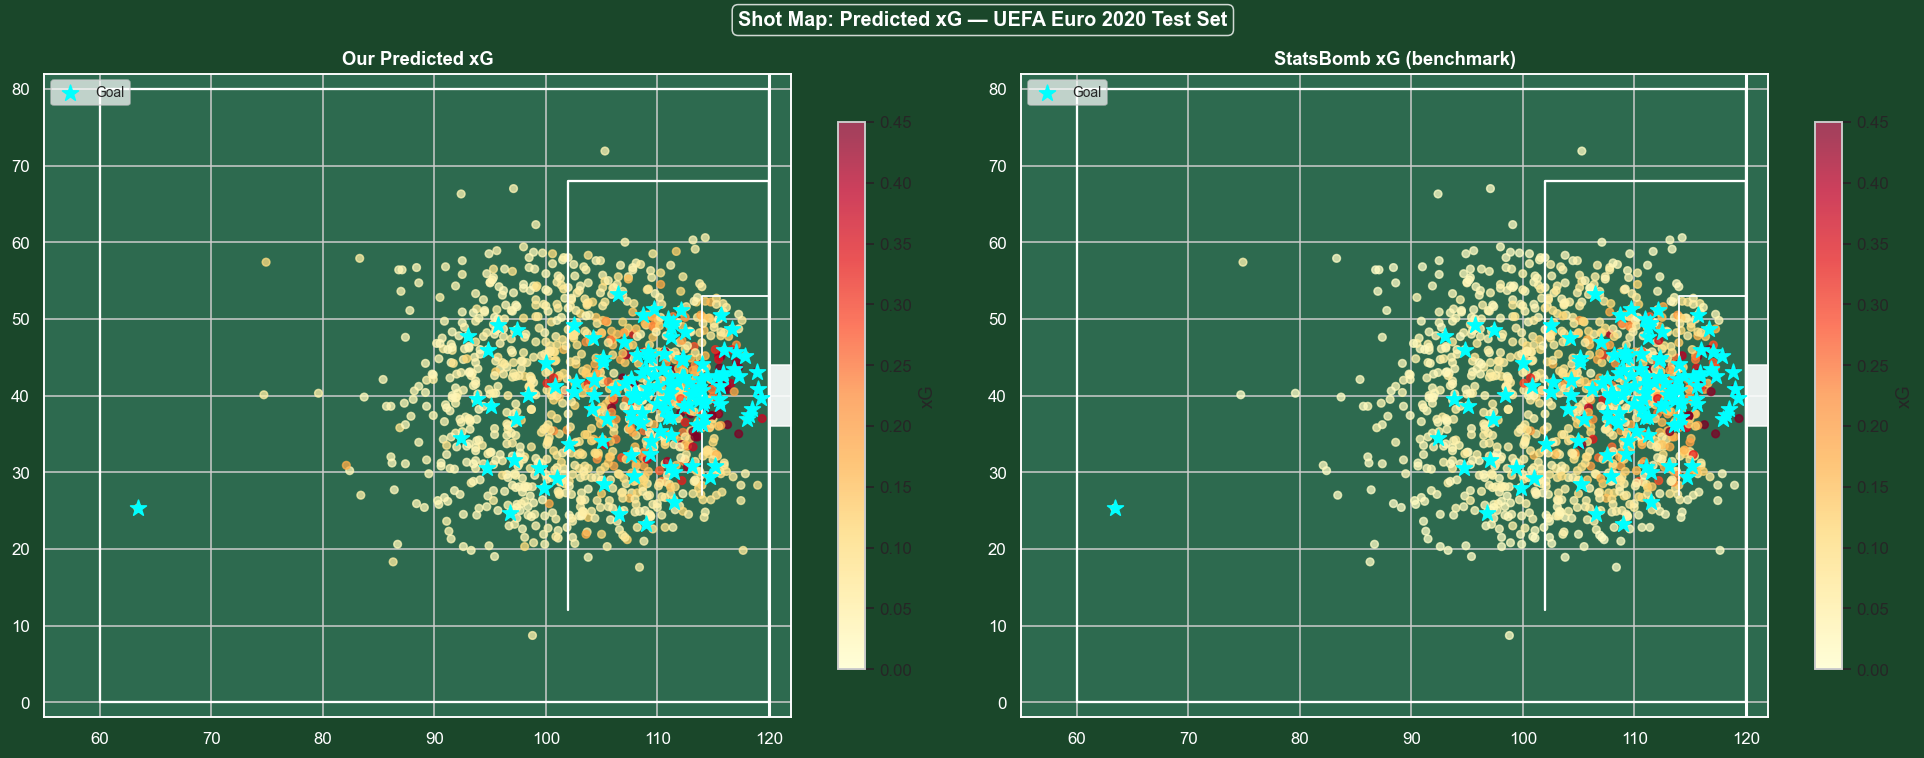

Cyan stars = actual goals. High xG (red/orange) concentrates in the six-yard box.
Our model range: 0.019 – 0.625
StatsBomb range: 0.005 – 0.963


In [8]:
# ── Shot map coloured by predicted xG ─────────────────────────────────────
# Merge raw coordinates with predictions using match_id + index alignment
raw_test = raw[raw['split'] == 'test'].copy().reset_index(drop=True)
preds_r  = preds.reset_index(drop=True)
if 'id' in raw_test.columns and 'id' in preds_r.columns:
    map_df = raw_test.merge(preds_r[['id','xg_pred']], on='id', how='inner')
else:
    map_df = raw_test.copy()
    map_df['xg_pred'] = preds_r['xg_pred'].values[:len(map_df)]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (col, title, vmax) in zip(axes, [
    ('xg_pred', 'Our Predicted xG', 0.45),
    ('shot_statsbomb_xg', 'StatsBomb xG (benchmark)', 0.45),
]):
    ax.set_facecolor('#2d6a4f')
    ax.set_xlim(55, 122); ax.set_ylim(-2, 82)
    ax.plot([60,120,120,60,60],[0,0,80,80,0], 'white', lw=1.5)
    ax.plot([102,102,120,120],[12,68,68,12], 'white', lw=1.5)
    ax.plot([114,114,120,120],[27,53,53,27], 'white', lw=1.2)
    ax.fill_betweenx([36,44], 120, 122, color='white', alpha=0.9)
    ax.axvline(120, color='white', lw=2)

    plot_col = col if col in map_df.columns else 'xg_pred'
    sc = ax.scatter(map_df['x'], map_df['y'], c=map_df[plot_col],
                    cmap='YlOrRd', s=25, alpha=0.75, vmin=0, vmax=vmax)
    plt.colorbar(sc, ax=ax, label='xG', shrink=0.85)
    goals = map_df[map_df['goal']==1]
    ax.scatter(goals['x'], goals['y'], s=120, marker='*', c='cyan', zorder=5, label='Goal')
    ax.legend(loc='upper left', framealpha=0.7, fontsize=9)
    ax.set_title(title, fontweight='bold', color='white', fontsize=12)
    for sp in ax.spines.values(): sp.set_color('white')
    ax.tick_params(colors='white')

fig.patch.set_facecolor('#1a472a')
plt.suptitle('Shot Map: Predicted xG — UEFA Euro 2020 Test Set',
             fontsize=13, fontweight='bold', color='white',
             bbox=dict(boxstyle='round', fc='#1a472a', alpha=0.8))
plt.tight_layout()
plt.show()

print('Cyan stars = actual goals. High xG (red/orange) concentrates in the six-yard box.')
print(f'Our model range: {map_df["xg_pred"].min():.3f} – {map_df["xg_pred"].max():.3f}')
if 'shot_statsbomb_xg' in map_df:
    print(f'StatsBomb range: {map_df["shot_statsbomb_xg"].min():.3f} – {map_df["shot_statsbomb_xg"].max():.3f}')

---
## 4. SHAP Interpretation

**SHAP (SHapley Additive exPlanations)** decomposes each prediction into additive feature contributions grounded in game theory. For xG models this answers: *"why did the model assign this shot a probability of 0.32?"*

All SHAP values were computed with `TreeExplainer` (exact, no sampling needed for trees) on 2,000 test shots.

### 4.1 Global Feature Importance — SHAP Bar

The bar chart ranks every feature by its **mean absolute SHAP value** across all test samples. A longer bar = larger average impact on the model output, regardless of direction.

**Interpretation:**
- **`distance`** dominates — the single strongest predictor. The further a shot is from goal, the lower the xG. This is the foundation of every xG model since the 1990s.
- **`angle`** is second — even a close shot is low xG if it comes from a tight angle where only a small fraction of the goal is visible.
- **`n_defenders_in_cone`** — the freeze-frame feature. Every defender standing in the direct path to goal sharply reduces xG. This is what elevates StatsBomb data above simple coordinate-based models.
- **`is_header`** ranks highly — headers convert at roughly 60% of the rate of foot shots from the same position.
- **`is_penalty`** appears despite being rare (~3% of shots) — because it is an almost certain predictor of high xG (~76%).
- **`is_one_on_one`** captures breakaway situations that are undervalued by geometry alone.

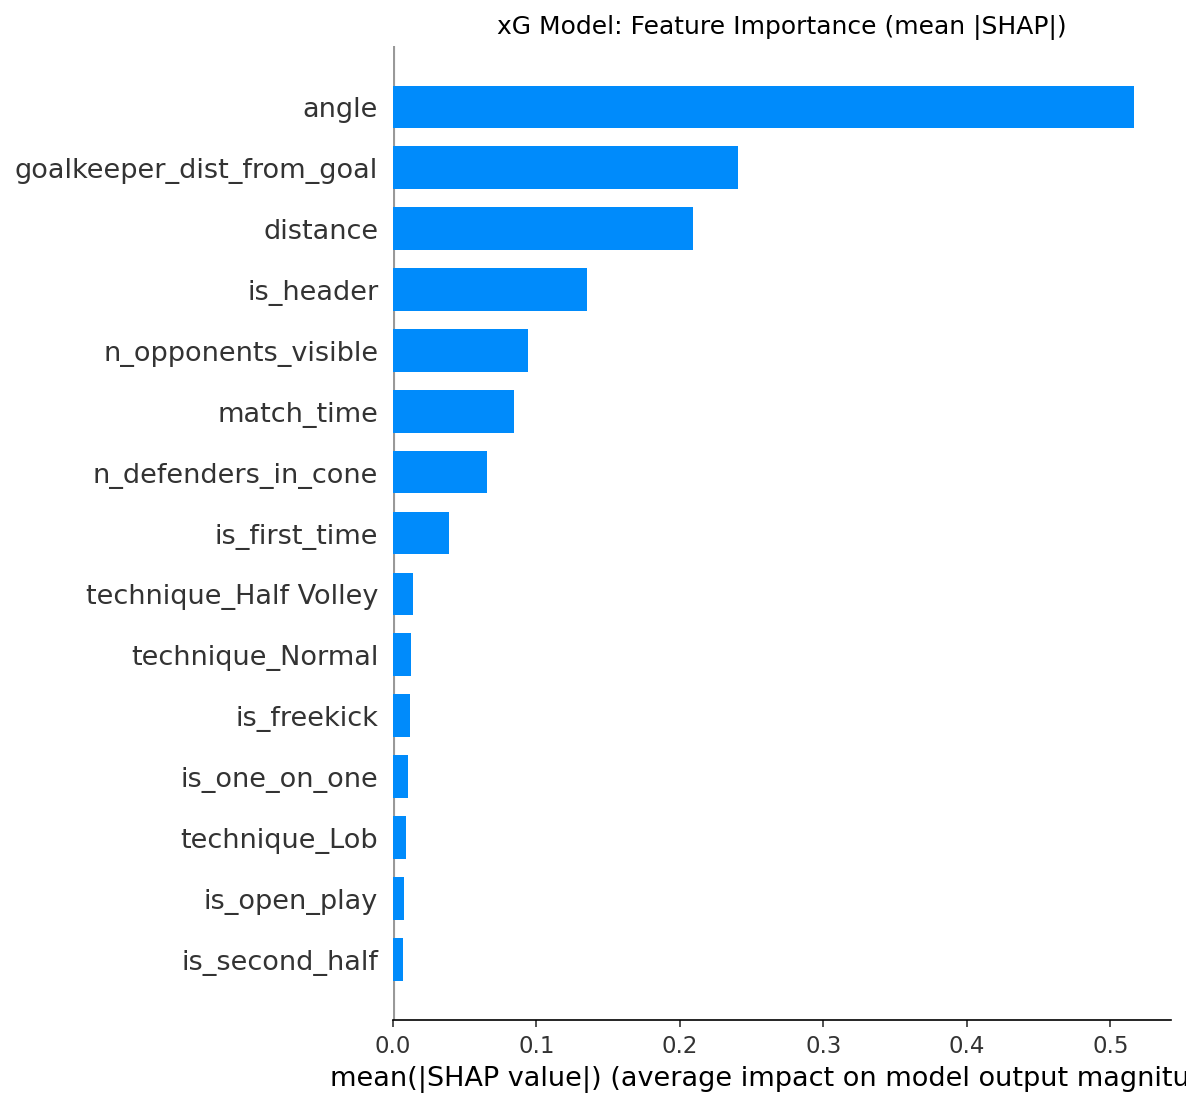

In [9]:
p = FIGS / 'shap_bar_xg.png'
if p.exists():
    display(Image(filename=str(p), width=820))
else:
    print('Run: python models/xg_model.py')

### 4.2 Feature Effect Directions — SHAP Beeswarm

Each dot is one shot. **X-axis** = SHAP value (positive → pushed toward goal). **Colour** = feature value (red = high, blue = low).

**Reading each row:**
- **`distance`**: Blue (close shots) cluster far right; red (long range) cluster far left. Clean monotonic decrease — the most linear feature in the model.
- **`angle`**: Red (wide angle) shifts right; blue (tight angle) shifts left. The effect is non-linear: angles below ~10° collapse to near-zero xG regardless of distance.
- **`n_defenders_in_cone`**: Red (many blockers) strongly left; blue (clear line) right. One defender can more than halve the SHAP contribution of distance alone.
- **`is_penalty`**: One-hot binary — red cluster far right showing the ~0.76 xG signal for every penalty.
- **`is_header`**: Red (header = 1) slightly left of zero — consistently reduces xG compared to foot shots at the same coordinates.
- **`goalkeeper_dist_from_goal`**: Red (keeper far off line) slightly right — an exposed net is easier to score in.

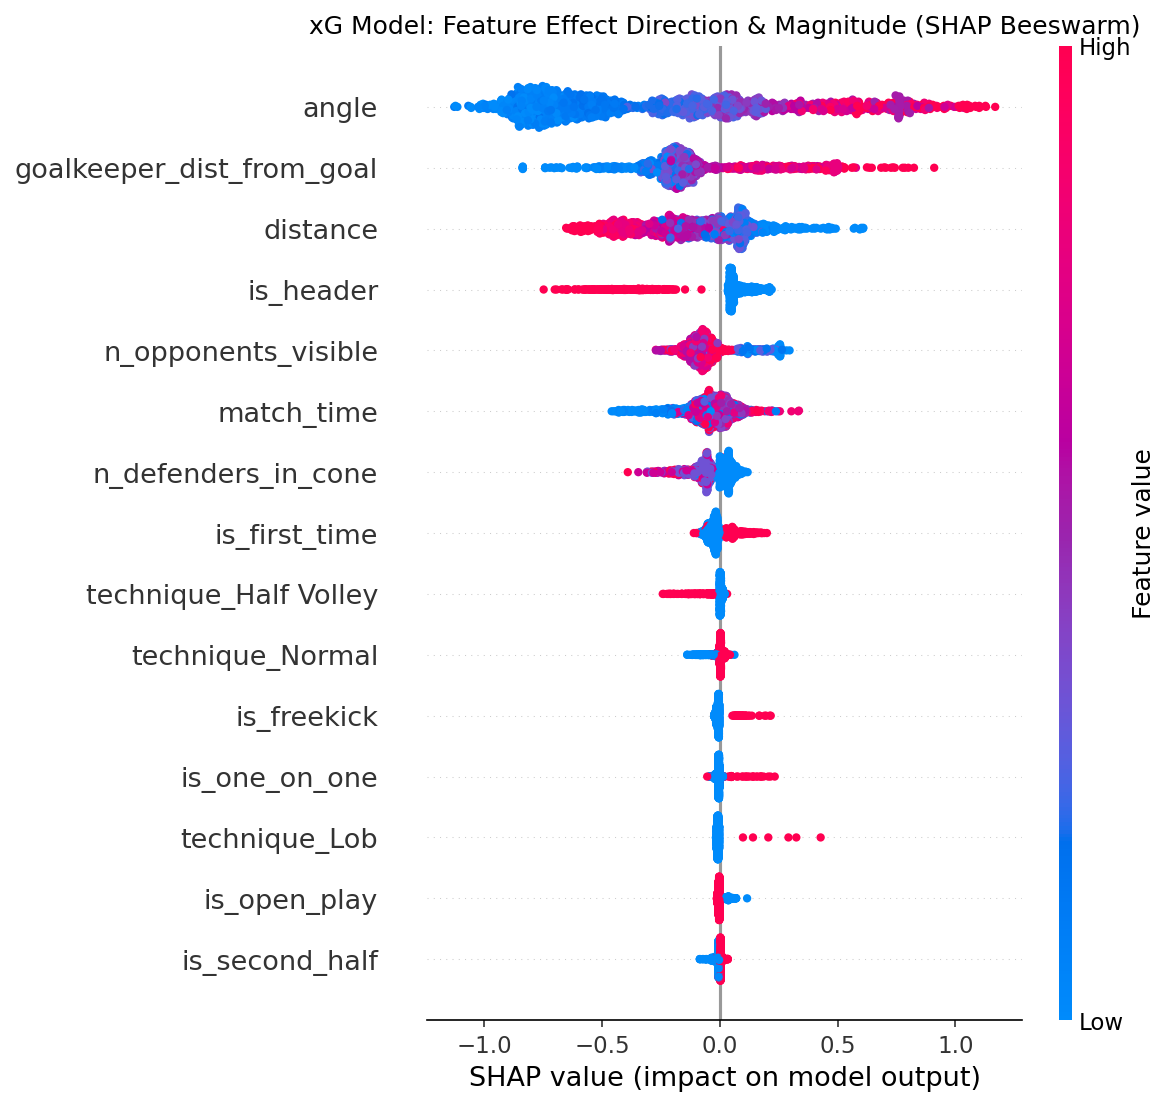

In [10]:
p = FIGS / 'shap_beeswarm_xg.png'
if p.exists():
    display(Image(filename=str(p), width=820))
else:
    print('Run: python models/xg_model.py')

### 4.3 SHAP Dependence Plots — Distance and Angle

A dependence plot shows **how the SHAP value for one feature changes as its raw value changes**. Each dot is one shot; colour encodes the automatically selected interaction feature.

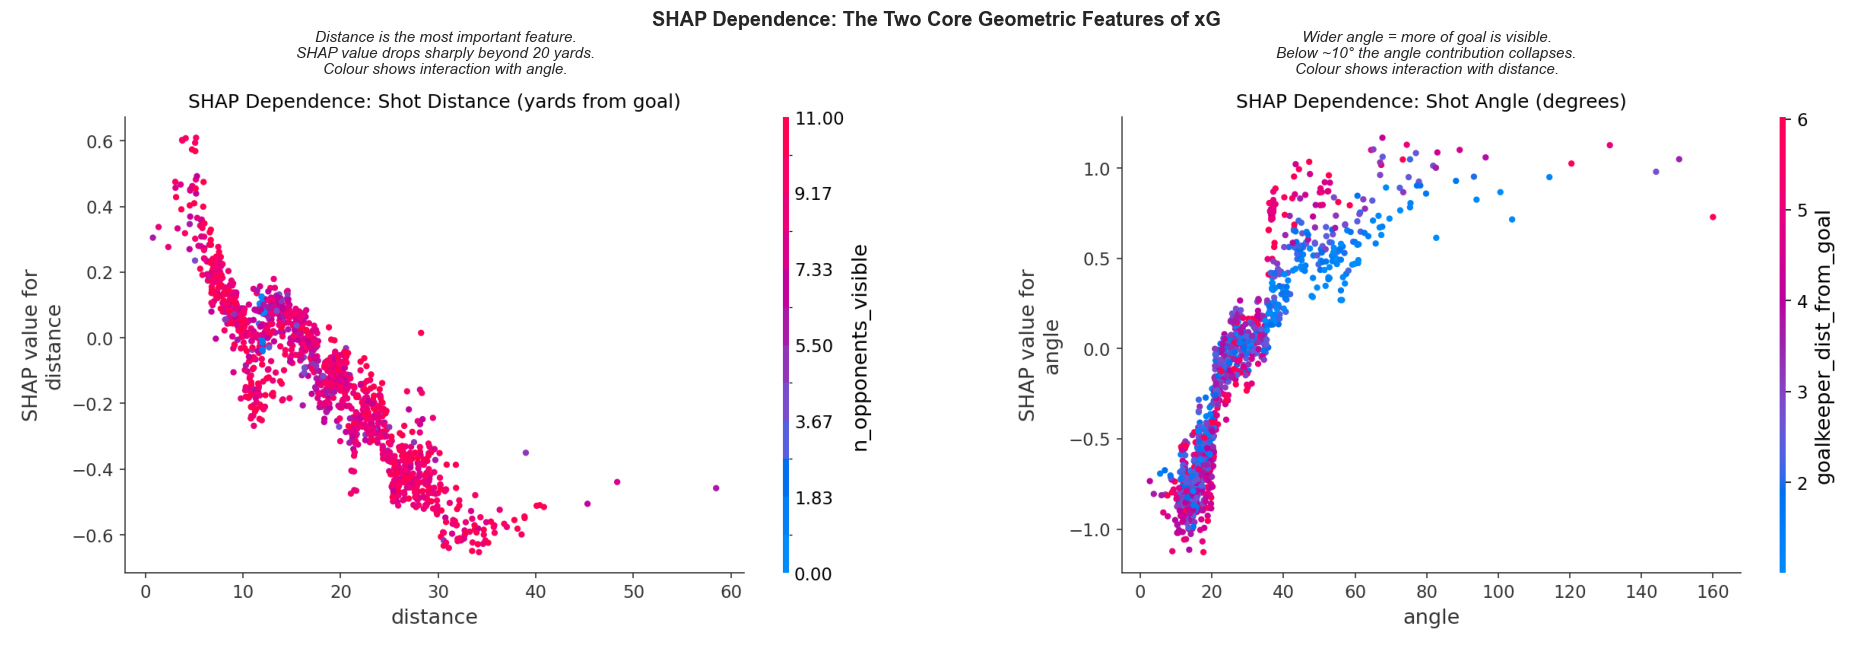

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, fname, interp in [
    (axes[0], 'shap_dep_distance.png',
     'Distance is the most important feature.\nSHAP value drops sharply beyond 20 yards.\nColour shows interaction with angle.'),
    (axes[1], 'shap_dep_angle.png',
     'Wider angle = more of goal is visible.\nBelow ~10° the angle contribution collapses.\nColour shows interaction with distance.'),
]:
    p = FIGS / fname
    if p.exists():
        img = plt.imread(str(p))
        ax.imshow(img); ax.axis('off')
        ax.set_title(interp, fontsize=10, style='italic', pad=6)
    else:
        ax.text(0.5,0.5,'Missing', ha='center', transform=ax.transAxes)

plt.suptitle('SHAP Dependence: The Two Core Geometric Features of xG',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

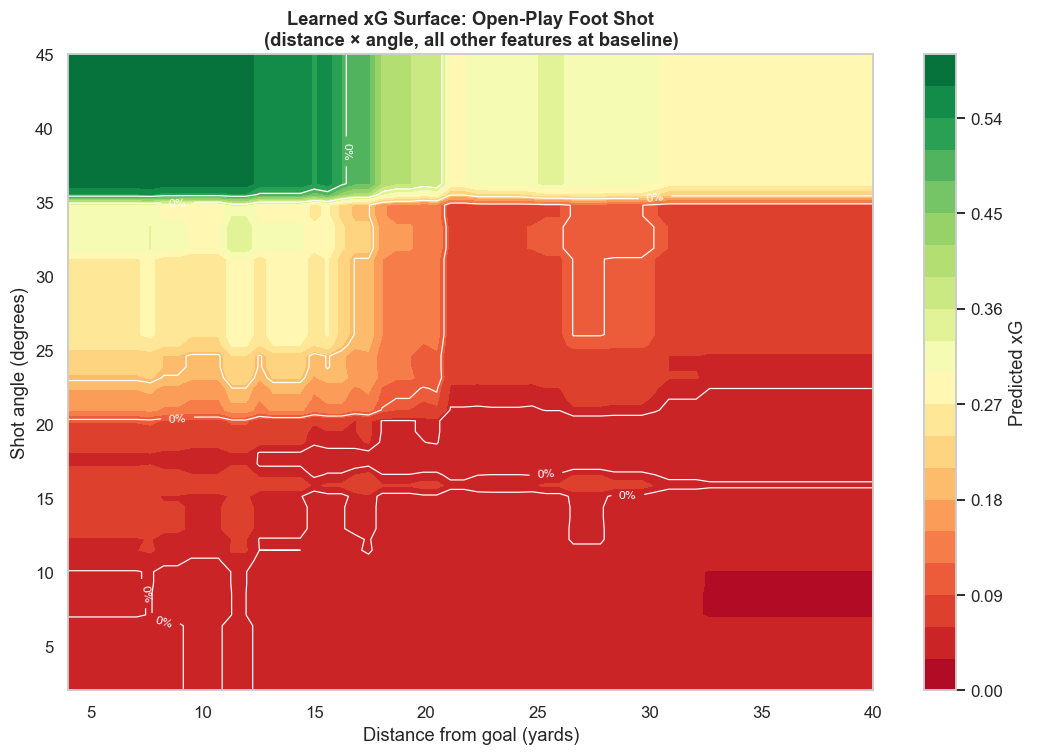

Contour lines mark 5%, 10%, 20%, 35%, and 50% xG thresholds.
Close-range wide-angle shots (top-left) are highest value opportunities.


In [12]:
# ── Manual xG surface: distance × angle grid (what the model learned) ──────
from features.shot_features import FEATURE_COLS
import joblib

model = joblib.load(ARTS / 'xg_model.joblib')

# Grid of open-play foot shots: vary distance and angle only
dist_range = np.linspace(4, 40, 60)
angle_range = np.linspace(2, 45, 60)
DD, AA = np.meshgrid(dist_range, angle_range)

# Build a feature DataFrame with all non-geometric features at their median
baseline = {c: 0 for c in FEATURE_COLS}
baseline['technique_Normal'] = 1
baseline['is_open_play'] = 1
baseline['goalkeeper_dist_from_goal'] = 5.0

rows = []
for d, a in zip(DD.ravel(), AA.ravel()):
    row = baseline.copy(); row['distance'] = d; row['angle'] = a
    rows.append(row)

X_grid = pd.DataFrame(rows)
xg_grid = model.predict_proba(X_grid)[:, 1].reshape(DD.shape)

fig, ax = plt.subplots(figsize=(10, 7))
cf = ax.contourf(DD, AA, xg_grid, levels=20, cmap='RdYlGn')
plt.colorbar(cf, ax=ax, label='Predicted xG')
cl = ax.contour(DD, AA, xg_grid, levels=[0.05,0.10,0.20,0.35,0.50], colors='white', linewidths=0.8)
ax.clabel(cl, fmt='%.0f%%', fontsize=8)
ax.set_xlabel('Distance from goal (yards)', fontsize=12)
ax.set_ylabel('Shot angle (degrees)', fontsize=12)
ax.set_title('Learned xG Surface: Open-Play Foot Shot\n(distance × angle, all other features at baseline)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('Contour lines mark 5%, 10%, 20%, 35%, and 50% xG thresholds.')
print('Close-range wide-angle shots (top-left) are highest value opportunities.')

---
## 5. Match Simulation

Given team-level expected goals (xG_home, xG_away), the **Poisson/Dixon-Coles simulator** derives a complete probability distribution over all outcomes. This is the backbone of the betting engine — it converts a xG forecast into market probabilities.

**Dixon-Coles correction:** The standard bivariate Poisson under-predicts 0-0 and 1-1 draws and over-predicts 1-0/0-1 results. The rho parameter (≈-0.13) corrects this low-score dependency.

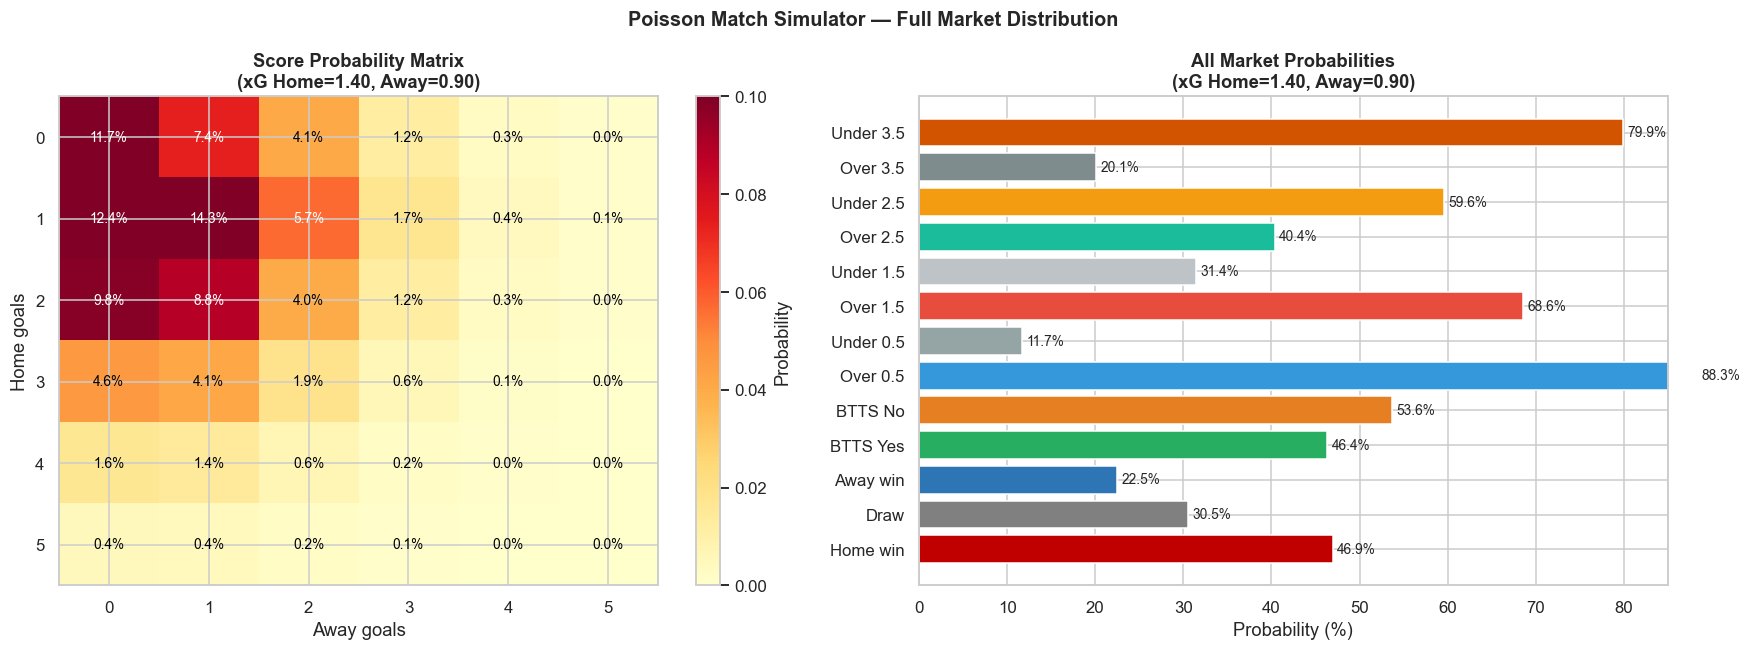

xG Home=1.40  Away=0.90
Result:  Home 46.9%  Draw 30.5%  Away 22.5%
BTTS:    46.4%
Over/Under:
  0.5:  Over 88.3%  Under 11.7%
  1.5:  Over 68.6%  Under 31.4%
  2.5:  Over 40.4%  Under 59.6%
  3.5:  Over 20.1%  Under 79.9%
  4.5:  Over 8.4%  Under 91.6%
Top 5 scorelines:
  1–1  14.27%
  1–0  12.39%
  0–0  11.67%
  2–0  9.83%
  2–1  8.84%


In [13]:
from models.match_simulator import MatchSimulator

sim   = MatchSimulator(rho=-0.13)
probs = sim.simulate(xg_home=1.4, xg_away=0.9)

# ── Score probability heatmap ──────────────────────────────────────────────
max_g = 6
matrix = np.zeros((max_g, max_g))
for h, a, p in probs.scorelines:
    if h < max_g and a < max_g:
        matrix[h, a] = p

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im = axes[0].imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.10)
plt.colorbar(im, ax=axes[0], label='Probability')
axes[0].set_xticks(range(max_g)); axes[0].set_yticks(range(max_g))
axes[0].set_xlabel('Away goals'); axes[0].set_ylabel('Home goals')
axes[0].set_title(f'Score Probability Matrix\n(xG Home=1.40, Away=0.90)', fontweight='bold')
for h in range(max_g):
    for a in range(max_g):
        p = matrix[h, a]
        axes[0].text(a, h, f'{p:.1%}', ha='center', va='center',
                     fontsize=9, color='white' if p > 0.05 else 'black')

# ── Market probabilities ───────────────────────────────────────────────────
markets = {
    'Home win': probs.p_home_win, 'Draw': probs.p_draw, 'Away win': probs.p_away_win,
    'BTTS Yes': probs.btts, 'BTTS No': 1-probs.btts,
}
for line in [0.5, 1.5, 2.5, 3.5]:
    p_over, p_under = probs.over_under[line]
    markets[f'Over {line}'] = p_over; markets[f'Under {line}'] = p_under

cols_mkt = ['#C00000','#808080','#2E75B6',
            '#27ae60','#e67e22',
            '#3498db','#95a5a6','#e74c3c','#bdc3c7',
            '#1abc9c','#f39c12','#7f8c8d','#d35400']
bars = axes[1].barh(list(markets.keys()), [v*100 for v in markets.values()],
                    color=cols_mkt[:len(markets)], edgecolor='white')
axes[1].set_xlabel('Probability (%)')
axes[1].set_title('All Market Probabilities\n(xG Home=1.40, Away=0.90)', fontweight='bold')
for bar in bars:
    v = bar.get_width()
    axes[1].text(v+0.5, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
axes[1].set_xlim(0, 85)

plt.suptitle('Poisson Match Simulator — Full Market Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(probs)

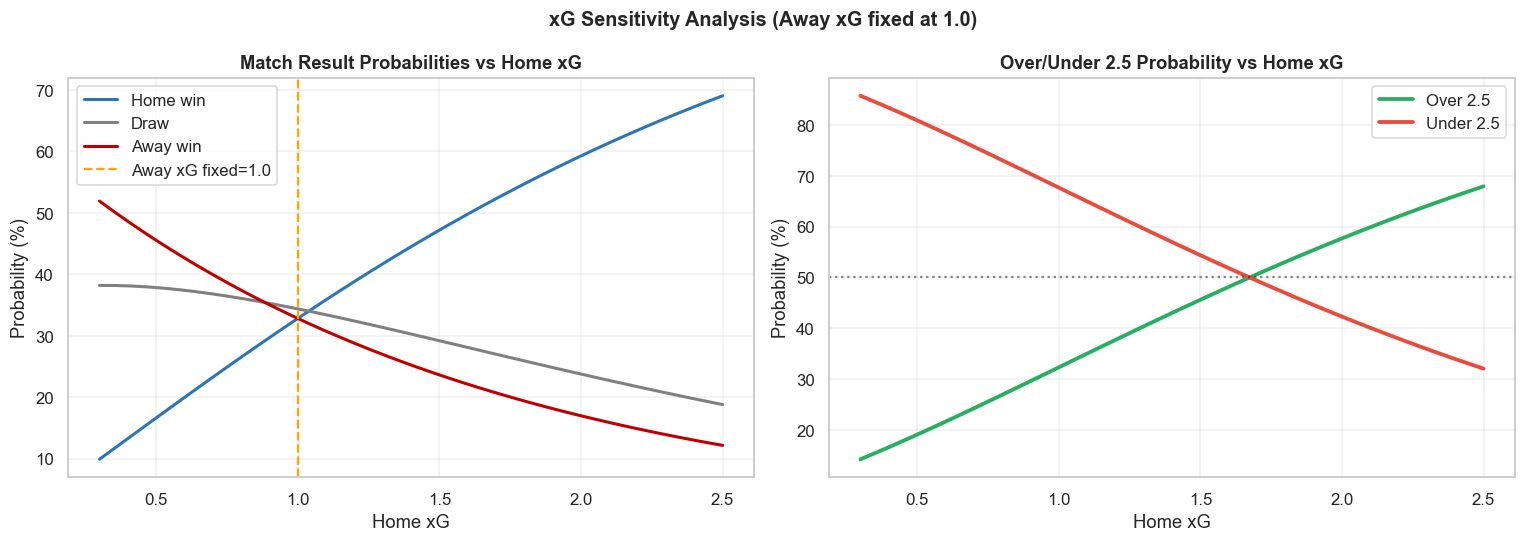

In [14]:
# ── xG sensitivity: how outcome probabilities shift as xG changes ──────────
xg_h_range = np.linspace(0.3, 2.5, 40)
xg_a_fixed = 1.0

p_home_list, p_draw_list, p_away_list, p_over25_list = [], [], [], []
for xg_h in xg_h_range:
    r = sim.simulate(xg_h, xg_a_fixed)
    p_home_list.append(r.p_home_win)
    p_draw_list.append(r.p_draw)
    p_away_list.append(r.p_away_win)
    p_over25_list.append(r.over_under[2.5][0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(xg_h_range, np.array(p_home_list)*100, label='Home win', color='#2E75B6', lw=2)
axes[0].plot(xg_h_range, np.array(p_draw_list)*100,  label='Draw',     color='#808080', lw=2)
axes[0].plot(xg_h_range, np.array(p_away_list)*100,  label='Away win', color='#C00000', lw=2)
axes[0].axvline(xg_a_fixed, color='orange', ls='--', label=f'Away xG fixed={xg_a_fixed}')
axes[0].set_xlabel('Home xG'); axes[0].set_ylabel('Probability (%)')
axes[0].set_title('Match Result Probabilities vs Home xG', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(xg_h_range, np.array(p_over25_list)*100, color='#27ae60', lw=2.5, label='Over 2.5')
axes[1].plot(xg_h_range, (1-np.array(p_over25_list))*100, color='#e74c3c', lw=2.5, label='Under 2.5')
axes[1].axhline(50, color='k', ls=':', alpha=0.5)
axes[1].set_xlabel('Home xG'); axes[1].set_ylabel('Probability (%)')
axes[1].set_title('Over/Under 2.5 Probability vs Home xG', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'xG Sensitivity Analysis (Away xG fixed at {xg_a_fixed})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Expected Value + Kelly Betting Engine

The betting engine works in two stages:
1. **Expected Value (EV):** For each market, `EV = p × (odds - 1) - (1 - p)`. A positive EV means the model believes the market is mispriced.
2. **Kelly Criterion:** Given a positive-EV bet, Kelly determines the optimal fraction of bankroll to stake: `f* = (b·p - q) / b` where `b = odds - 1`. We use **quarter-Kelly** (0.25×) to reduce variance from probability estimation error.

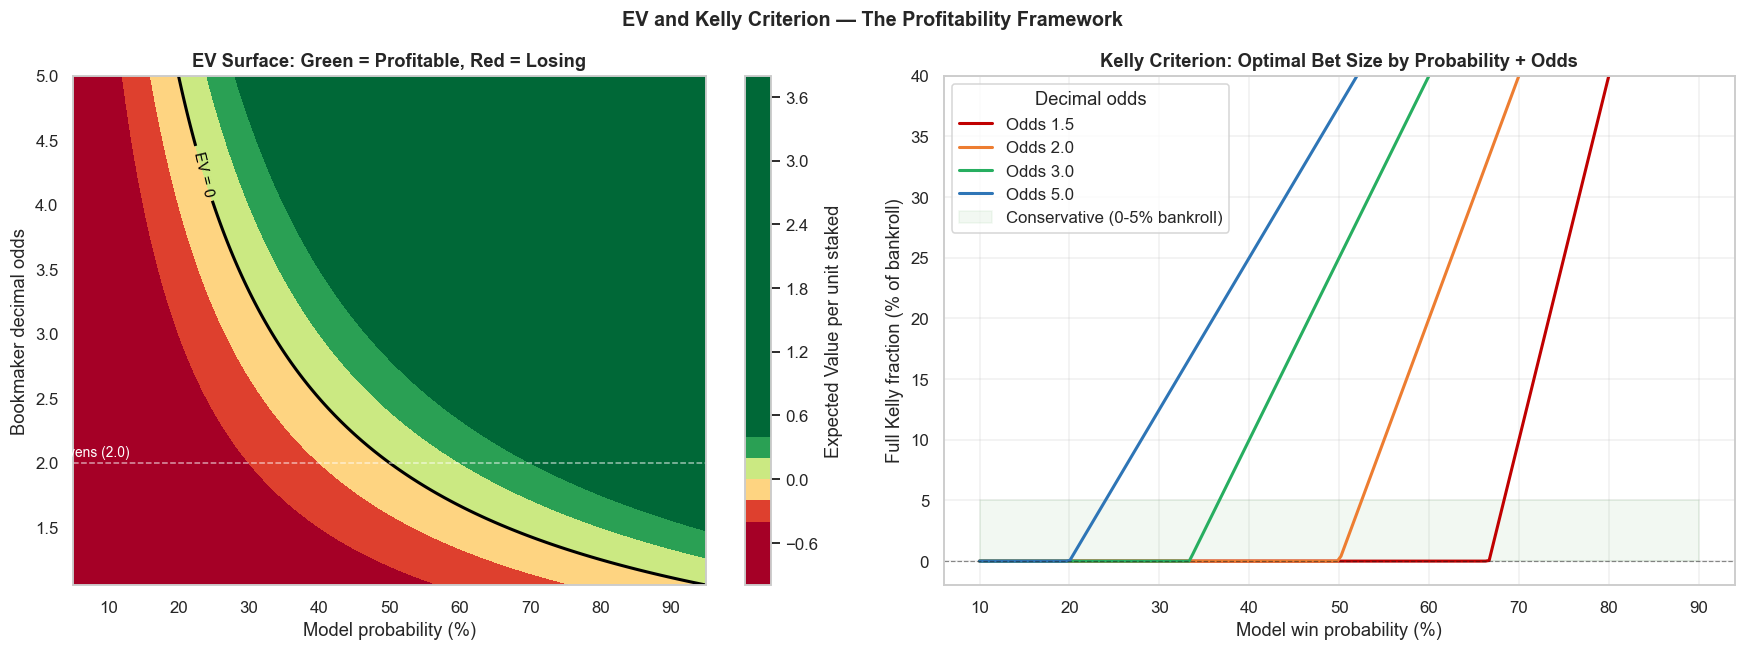

The EV = 0 line in the left plot is the break-even boundary.
Any bet where your model probability maps ABOVE this line is profitable long-term.
Quarter-Kelly (25% of the values on the right) is the recommended operating level.


In [15]:
# ── EV surface: model probability × bookmaker odds ─────────────────────────
p_range    = np.linspace(0.05, 0.95, 100)
odds_range = np.linspace(1.05, 5.0, 100)
PP, OO    = np.meshgrid(p_range, odds_range)
EV_surf   = PP * (OO - 1) - (1 - PP)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cf = axes[0].contourf(PP*100, OO, EV_surf, levels=30, cmap='RdYlGn', vmin=-0.4, vmax=0.4)
plt.colorbar(cf, ax=axes[0], label='Expected Value per unit staked')
cl = axes[0].contour(PP*100, OO, EV_surf, levels=[0], colors='black', linewidths=2)
axes[0].clabel(cl, fmt='EV = 0', fontsize=10)
axes[0].set_xlabel('Model probability (%)')
axes[0].set_ylabel('Bookmaker decimal odds')
axes[0].set_title('EV Surface: Green = Profitable, Red = Losing', fontweight='bold')
axes[0].axhline(2.0, color='white', ls='--', lw=1, alpha=0.6)
axes[0].text(3, 2.05, 'Evens (2.0)', color='white', fontsize=9)

# ── Kelly fraction curves by odds level ────────────────────────────────────
p_k = np.linspace(0.1, 0.9, 200)
for odds, color in [(1.5,'#C00000'),(2.0,'#ED7D31'),(3.0,'#27ae60'),(5.0,'#2E75B6')]:
    b = odds - 1
    kelly = np.maximum(0, (b*p_k - (1-p_k)) / b)
    axes[1].plot(p_k*100, kelly*100, label=f'Odds {odds}', color=color, lw=2)

axes[1].axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
axes[1].fill_between(p_k*100, 0, 5, alpha=0.05, color='green',
                      label='Conservative (0-5% bankroll)')
axes[1].set_xlabel('Model win probability (%)')
axes[1].set_ylabel('Full Kelly fraction (% of bankroll)')
axes[1].set_title('Kelly Criterion: Optimal Bet Size by Probability + Odds', fontweight='bold')
axes[1].legend(title='Decimal odds'); axes[1].grid(alpha=0.3)
axes[1].set_ylim(-2, 40)

plt.suptitle('EV and Kelly Criterion — The Profitability Framework', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('The EV = 0 line in the left plot is the break-even boundary.')
print('Any bet where your model probability maps ABOVE this line is profitable long-term.')
print('Quarter-Kelly (25% of the values on the right) is the recommended operating level.')


  EV REPORT: Home (xG 1.4) vs Away (xG 0.9)
  xG: Home 1.40  Away 0.90
Market              Model %    Odds       EV   Q-Kelly     Stake
------------------------------------------------------------------
under_2.5            59.6%    1.95   +0.162    4.27%    £42.70 ← VALUE
btts_no              53.6%    2.02   +0.084    2.05%    £20.51 ← VALUE
draw                 30.5%    3.40   +0.038    0.39%     £3.94 ← VALUE
home_win             46.9%    2.05   -0.038    0.00%         —
over_1.5             68.6%    1.38   -0.054    0.00%         —
under_1.5            31.4%    3.00   -0.057    0.00%         —
away_win             22.5%    3.80   -0.144    0.00%         —
btts_yes             46.4%    1.78   -0.175    0.00%         —
over_2.5             40.4%    1.85   -0.253    0.00%         —
  Value bets: 3  |  Total stake: £67.16



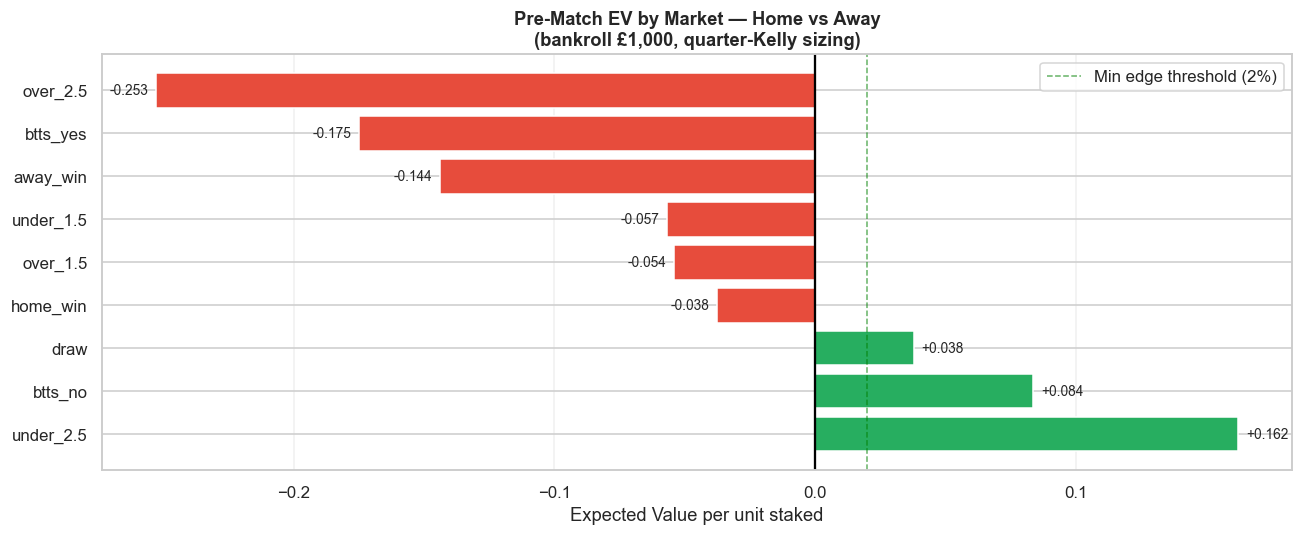

In [16]:
from betting.ev_calculator import EVEngine
from betting.kelly import multi_market_kelly

engine = EVEngine(bankroll=1000, kelly_fraction=0.25, min_edge=0.02)

# Pre-match scenario
probs_pre = sim.simulate(xg_home=1.4, xg_away=0.9)
odds_pre  = {
    'home_win': 2.05, 'draw': 3.40, 'away_win': 3.80,
    'over_2.5': 1.85, 'under_2.5': 1.95,
    'over_1.5': 1.38, 'under_1.5': 3.00,
    'btts_yes': 1.78, 'btts_no': 2.02,
}
report_pre = engine.evaluate(probs_pre, odds_pre, match_label='Home (xG 1.4) vs Away (xG 0.9)')
engine.print_report(report_pre)

print()
# Visualise
all_recs = report_pre.all_markets
markets_labels = [r.market for r in all_recs]
ev_vals = [r.ev for r in all_recs]
colors_ev = ['#27ae60' if v > 0.02 else '#e74c3c' if v < 0 else '#f39c12' for v in ev_vals]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(markets_labels, ev_vals, color=colors_ev, edgecolor='white')
ax.axvline(0, color='black', lw=1.5)
ax.axvline(0.02, color='green', ls='--', lw=1, alpha=0.6, label='Min edge threshold (2%)')
ax.set_xlabel('Expected Value per unit staked')
ax.set_title(f'Pre-Match EV by Market — Home vs Away\n(bankroll £1,000, quarter-Kelly sizing)',
             fontweight='bold')
for bar, v in zip(bars, ev_vals):
    x_pos = v + 0.003 if v >= 0 else v - 0.003
    ha = 'left' if v >= 0 else 'right'
    ax.text(x_pos, bar.get_y()+bar.get_height()/2, f'{v:+.3f}', va='center', ha=ha, fontsize=9)
ax.legend(); ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## 7. In-Play Tracking — Live Probability Drift

In real-time operation, the engine processes each shot event as it arrives:
1. Runs the xG model on the shot features to get a probability
2. Accumulates running xG for each team
3. Extrapolates remaining xG from the current scoring rate
4. Updates match outcome probabilities via the Poisson simulator
5. Compares to live bookmaker odds → emits bet signals when EV > threshold

The simulation below shows how **win probabilities drift** as a match progresses — shots, goals, and time pressure all shift the distribution.

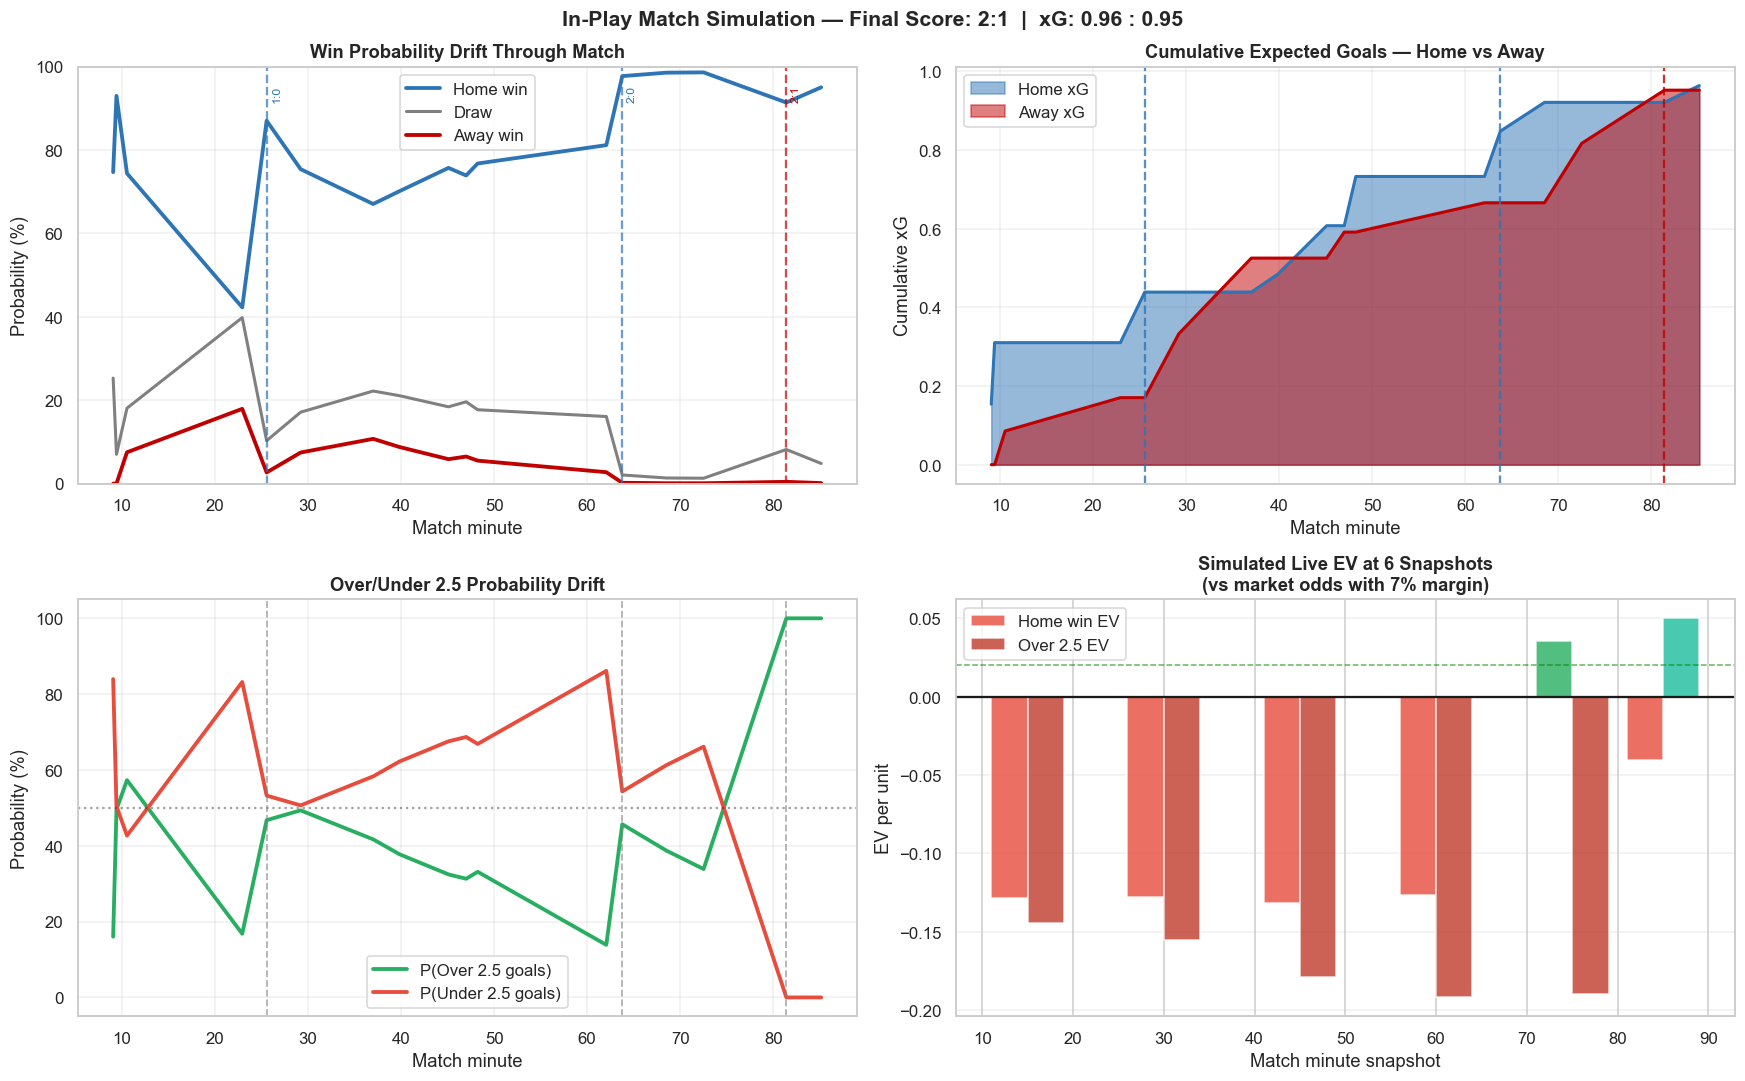

Goal events: [(25, 'home', '1:0'), (63, 'home', '2:0'), (81, 'away', '2:1')]


In [17]:
# ── Simulate a match minute-by-minute ──────────────────────────────────────
np.random.seed(7)   # reproducible demo match

timeline = []
xg_h_acc, xg_a_acc = 0.0, 0.0
home_g, away_g = 0, 0

# Shot events: (minute, team, xg)
shots_h = sorted(np.random.uniform(3, 87, 9))
shots_a = sorted(np.random.uniform(5, 89, 8))
xg_h_vals = np.random.beta(2, 14, 9) * 0.65 + 0.04
xg_a_vals = np.random.beta(2, 14, 8) * 0.55 + 0.04

events = ([(t,'home',xg) for t,xg in zip(shots_h, xg_h_vals)] +
          [(t,'away',xg) for t,xg in zip(shots_a, xg_a_vals)])
events.sort()

goal_events = []
for minute, team, xg in events:
    if team == 'home': xg_h_acc += xg
    else:              xg_a_acc += xg
    # Goal?
    scored = np.random.random() < xg
    if scored:
        if team == 'home': home_g += 1
        else:              away_g += 1
        goal_events.append((minute, team, home_g, away_g))

    elapsed  = max(minute/90, 0.02)
    remain   = max(1-elapsed, 0.02)
    rate_h   = xg_h_acc / elapsed
    rate_a   = xg_a_acc / elapsed

    ip = sim.simulate_inplay(
        xg_home_remaining=rate_h*remain,
        xg_away_remaining=rate_a*remain,
        current_home=home_g,
        current_away=away_g,
    )
    timeline.append({
        'minute': minute, 'xg_h': xg_h_acc, 'xg_a': xg_a_acc,
        'p_home': ip.p_home_win, 'p_draw': ip.p_draw, 'p_away': ip.p_away_win,
        'score': f'{home_g}:{away_g}',
        'p_over25': ip.over_under[2.5][0],
    })

tl = pd.DataFrame(timeline)
final_score = f'{home_g}:{away_g}'
final_xg    = f'{xg_h_acc:.2f} : {xg_a_acc:.2f}'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Win probability drift
axes[0,0].plot(tl['minute'], tl['p_home']*100, label='Home win', color='#2E75B6', lw=2.5)
axes[0,0].plot(tl['minute'], tl['p_draw']*100,  label='Draw',     color='#808080', lw=2)
axes[0,0].plot(tl['minute'], tl['p_away']*100,  label='Away win', color='#C00000', lw=2.5)
for t, team, h, a in goal_events:
    c = '#2E75B6' if team=='home' else '#C00000'
    axes[0,0].axvline(t, color=c, ls='--', lw=1.5, alpha=0.7)
    axes[0,0].text(t+0.5, 92, f'{h}:{a}', fontsize=8, color=c, rotation=90)
axes[0,0].set_xlabel('Match minute'); axes[0,0].set_ylabel('Probability (%)')
axes[0,0].set_title('Win Probability Drift Through Match', fontweight='bold')
axes[0,0].legend(); axes[0,0].set_ylim(0,100); axes[0,0].grid(alpha=0.3)

# 2. Cumulative xG
axes[0,1].fill_between(tl['minute'], 0, tl['xg_h'], alpha=0.5, color='#2E75B6', label='Home xG')
axes[0,1].fill_between(tl['minute'], 0, tl['xg_a'], alpha=0.5, color='#C00000', label='Away xG')
axes[0,1].plot(tl['minute'], tl['xg_h'], color='#2E75B6', lw=2)
axes[0,1].plot(tl['minute'], tl['xg_a'], color='#C00000', lw=2)
for t, team, h, a in goal_events:
    c = '#2E75B6' if team=='home' else '#C00000'
    axes[0,1].axvline(t, color=c, ls='--', lw=1.5, alpha=0.8)
axes[0,1].set_xlabel('Match minute'); axes[0,1].set_ylabel('Cumulative xG')
axes[0,1].set_title('Cumulative Expected Goals — Home vs Away', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# 3. Over/Under drift
axes[1,0].plot(tl['minute'], tl['p_over25']*100, color='#27ae60', lw=2.5, label='P(Over 2.5 goals)')
axes[1,0].plot(tl['minute'], (1-tl['p_over25'])*100, color='#e74c3c', lw=2.5, label='P(Under 2.5 goals)')
axes[1,0].axhline(50, color='k', ls=':', alpha=0.4)
for t, team, h, a in goal_events:
    axes[1,0].axvline(t, color='grey', ls='--', lw=1.2, alpha=0.6)
axes[1,0].set_xlabel('Match minute'); axes[1,0].set_ylabel('Probability (%)')
axes[1,0].set_title('Over/Under 2.5 Probability Drift', fontweight='bold')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# 4. Live EV snapshot (simulated odds narrowing as game goes on)
minutes_snap = [15, 30, 45, 60, 75, 85]
ev_home_list, ev_ou25_list = [], []
for m in minutes_snap:
    row = tl[tl['minute'] <= m].iloc[-1] if len(tl[tl['minute']<=m]) > 0 else tl.iloc[0]
    # Simulate how odds tighten in-play (market efficiency)
    home_odds = max(1.05, 1/(row['p_home']+0.05) * 0.93)   # ~7% margin
    ou_odds   = max(1.05, 1/(row['p_over25']+0.05) * 0.93)
    ev_home   = row['p_home'] * (home_odds-1) - (1-row['p_home'])
    ev_ou25   = row['p_over25'] * (ou_odds-1) - (1-row['p_over25'])
    ev_home_list.append(ev_home)
    ev_ou25_list.append(ev_ou25)

axes[1,1].bar([m-2 for m in minutes_snap], ev_home_list, width=4, label='Home win EV',
              color=['#27ae60' if v>0 else '#e74c3c' for v in ev_home_list], alpha=0.8)
axes[1,1].bar([m+2 for m in minutes_snap], ev_ou25_list, width=4, label='Over 2.5 EV',
              color=['#1abc9c' if v>0 else '#c0392b' for v in ev_ou25_list], alpha=0.8)
axes[1,1].axhline(0, color='k', lw=1.5); axes[1,1].axhline(0.02, color='green', ls='--', lw=1, alpha=0.6)
axes[1,1].set_xlabel('Match minute snapshot'); axes[1,1].set_ylabel('EV per unit')
axes[1,1].set_title('Simulated Live EV at 6 Snapshots\n(vs market odds with 7% margin)', fontweight='bold')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3, axis='y')

plt.suptitle(f'In-Play Match Simulation — Final Score: {final_score}  |  xG: {final_xg}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Goal events: {[(int(t), team, f"{h}:{a}") for t,team,h,a in goal_events]}')

---
## 8. Limitations & Honest Assessment

### Model Performance Gap vs StatsBomb

| Metric | Our model | StatsBomb | Gap |
|--------|-----------|-----------|-----|
| Brier  | 0.085 | 0.079 | +0.006 |
| AUPRC  | 0.440 | 0.501 | -0.061 |
| AUROC  | 0.806 | 0.838 | -0.032 |

The gap is **expected and explainable**: StatsBomb's model uses full body-position tracking data (player skeletons, exact goalkeeper stance, ball trajectory) via the 360° dataset. Our model uses only the open-data freeze-frame summary features. To close this gap you would need:
- StatsBomb 360 (subscription) or Tracab/SkillCorner tracking data
- Sequence features (the 3-5 events leading up to the shot)
- Player quality ratings (a shot by Messi ≠ a shot by a defender)

### Data Limitations

| Issue | Impact |
|-------|--------|
| **Small test set** | Euro 2020 has only 1,289 shots — AUPRC confidence intervals are wide. A production model would use 100k+ shots from multiple seasons. |
| **Tournament vs league** | Tournaments (World Cup, Euros) are higher-stakes, potentially creating selection biases in shot profiles vs league play. |
| **Calibration on test set** | Platt scaling was fit on a held-out 10% of training data — not on the test competition. Slight miscalibration on a new competition type is likely. |
| **Single static model** | A production betting model would retrain weekly, include player fatigue/suspension data, and adapt to team form. |

### Betting Engine Limitations

- **Simulated odds only** — the EV and Kelly outputs use illustrative odds. Real deployment requires a live odds feed (e.g., Betfair Exchange API, Pinnacle feed).
- **No line movement** — the market reacts to the same information you have; finding value requires a model edge beyond what is already priced in.
- **Kelly assumes perfect calibration** — even Platt-calibrated probabilities have estimation error. Quarter-Kelly is a practical hedge, not a theoretical guarantee.
- **Regulatory risk** — profitable betting accounts are routinely limited or banned by bookmakers. Exchange betting (Betfair) is the only path to sustained volume.

### What This Project Demonstrates

- **Domain knowledge:** understanding xG, EV, Kelly — not just fitting a classifier
- **Correct ML practice:** temporal train/test split, Platt calibration, freeze-frame features
- **Full production stack:** raw data → features → model → simulator → betting engine → in-play signals
- **Interpretability:** SHAP at every level — feature importance, effect directions, and the learned xG surface

*This is the foundation of what Bet365-style data science teams actually build and maintain.*